# Professor-Level Analysis

This notebook analyzes:
- CAPES data filtered by professor
- RateMyProfessors (RMP) ratings
- Cross-reference: RMP rating vs actual GPA received


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
root_dir = next((path for path in [cwd, *cwd.parents] if (path / "src").exists() and (path / "data" / "capes_data.csv").exists()), None)
if root_dir is None:
    raise FileNotFoundError("Could not find the project root from the current notebook working directory.")
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.capes_analysis import clean_capes_analysis_frame, load_capes_data, load_provider_release_frames, provider_frames_to_quarter_events
from src import professor_helpers as ph

df_raw = load_capes_data(root_dir / 'data' / 'capes_data.csv')
rmp_profs, rmp_reviews = ph.load_rmp_data(root_dir)
provider_frames = load_provider_release_frames(root_dir / 'data')
all_llm_events = provider_frames_to_quarter_events(provider_frames, min_year=2020, max_year=2024)

print(f'CAPES rows: {len(df_raw):,}')
print(f'RMP professor rows: {len(rmp_profs):,}')
print(f'RMP review rows: {len(rmp_reviews):,}')



CAPES rows: 63,363
RMP professor rows: 4,003
RMP review rows: 38,696


## 2. Clean CAPES Data

In [2]:
df_clean = clean_capes_analysis_frame(df_raw).dropna(subset=['Instructor'])
print(f'Clean rows: {len(df_clean):,}')
df_clean[['Instructor', 'Course', 'Quarter', 'GPA_Received', 'Pct_Rec_Prof']].head()


Clean rows: 41,179


,Instructor,Course,Quarter,GPA_Received,Pct_Rec_Prof
0,Butler Elizabeth Annette,AAS 10 - Intro/African-American Studies (A),SP23,3.67,100.0
1,Butler Elizabeth Annette,AAS 170 - Legacies of Research (A),SP23,3.92,100.0
3,Shtienberg Gilad,ANAR 115 - Coastal Geomorphology/Environ (A),SP23,3.07,83.3
4,Braswell Geoffrey E.,ANAR 155 - Stdy Abrd: Ancient Mesoamerica (A),SP23,4.00,100.0
5,Hrvoj Mihic Branka,ANBI 111 - Human Evolution (A),SP23,2.95,100.0


## 3. Professor-Level CAPES Analysis

### 3.1 Top & Bottom Professors by Average GPA (min 5 courses)

Professors with >= 5 courses: 2,085


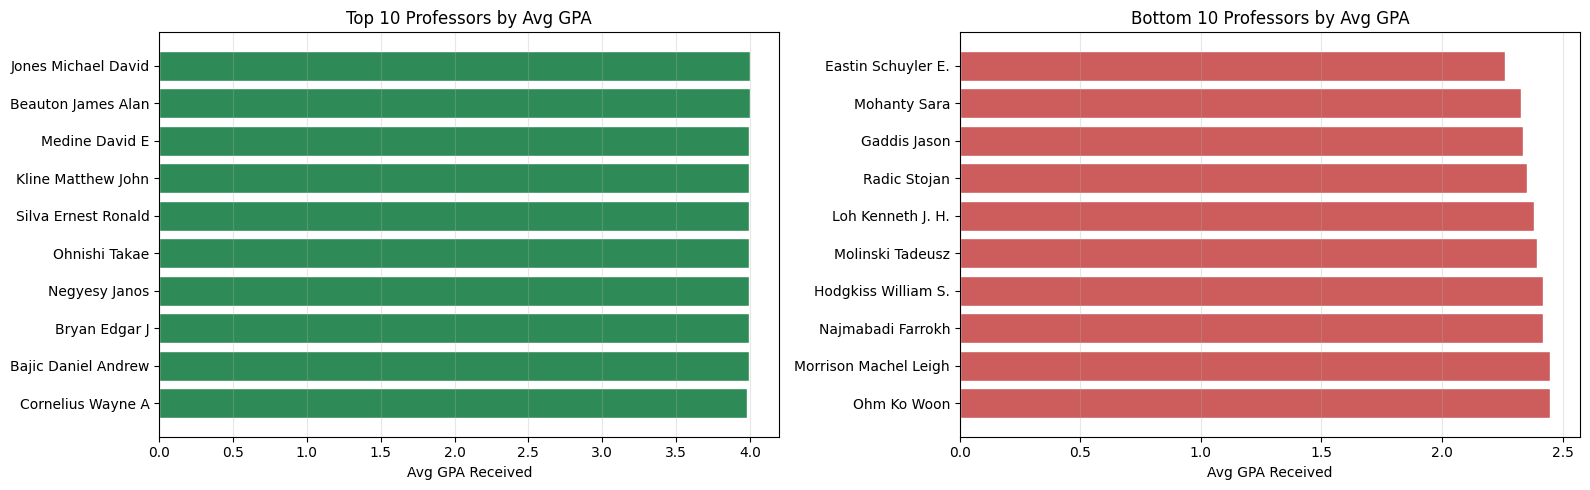

In [3]:
prof_stats = ph.summarize_professors(df_clean, min_courses=5)
print(f'Professors with >= 5 courses: {len(prof_stats):,}')

top10, bottom10 = ph.top_and_bottom_professors(prof_stats)
ph.plot_top_bottom_professors(top10, bottom10, 'figures/prof_top_bottom_gpa.png')


### 3.2 GPA Trend for a Specific Professor Over Time

Top 5 by course count: ['Walsh Kim C.', 'Anderson Michael G.', 'Chang Edmond Yi-Teh', 'Houskeeper Robert', 'Chen Pei-Chia']


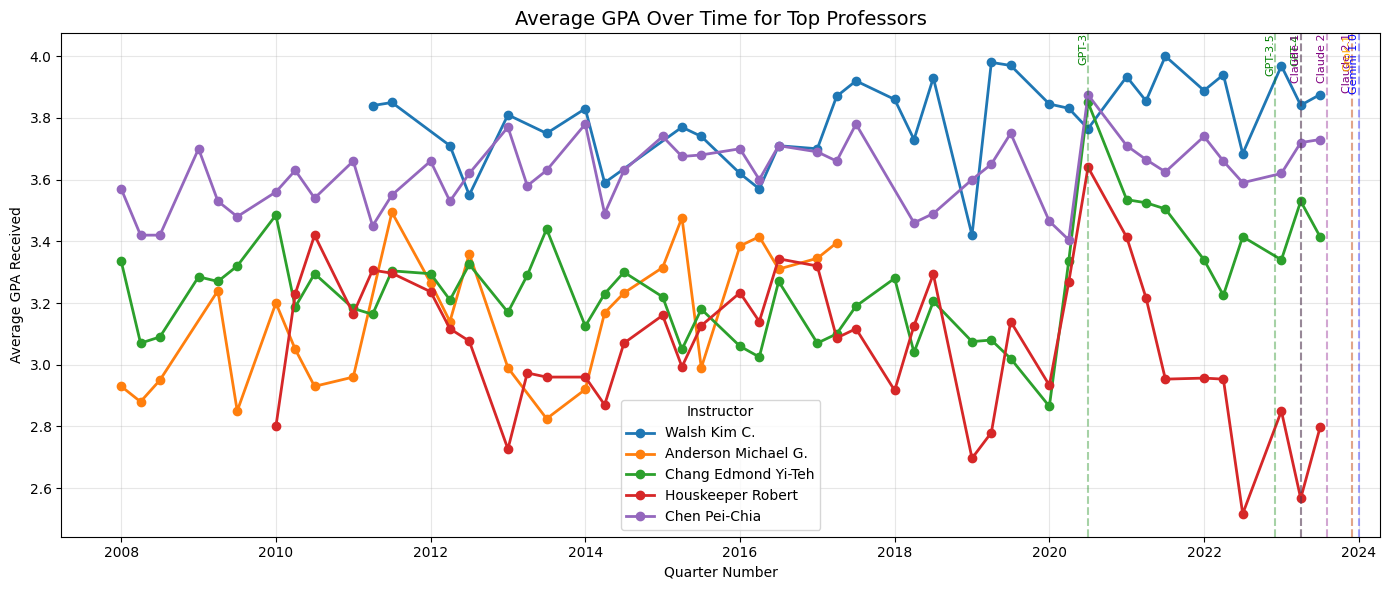

In [4]:
top5_profs = ph.top_professors_by_count(prof_stats)
print('Top 5 by course count:', top5_profs)
ph.plot_professor_trends(df_clean, top5_profs, all_llm_events, 'figures/prof_gpa_trend.png')


### 3.3 Recommendation Rate vs GPA — Scatter per Professor

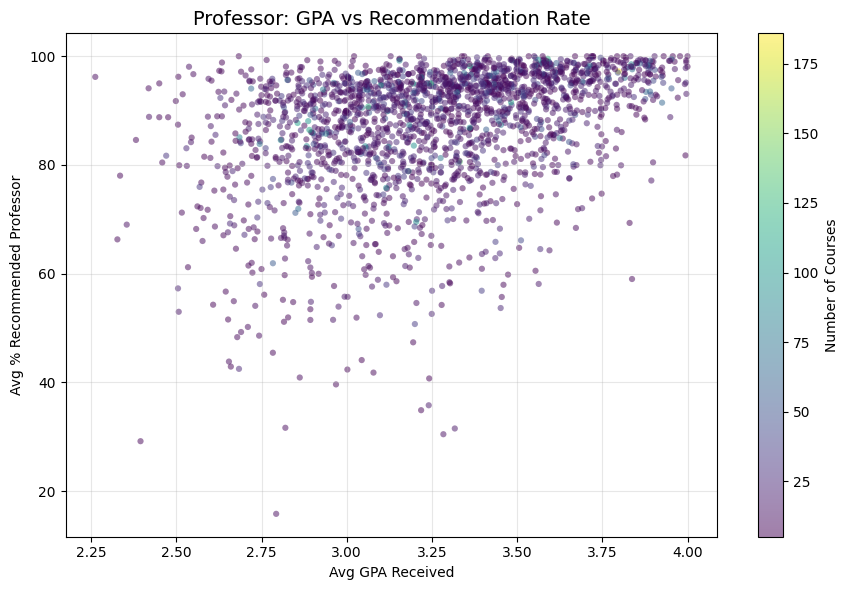

Correlation (avg GPA vs avg rec): 0.364


In [5]:
corr = ph.plot_professor_gpa_vs_recommendation(prof_stats, 'figures/prof_gpa_vs_rec.png')
print(f'Correlation (avg GPA vs avg rec): {corr:.3f}')


## 4. RateMyProfessors Analysis

### 4.1 RMP Overview

In [6]:
print('RMP Professors columns:', rmp_profs.columns.tolist())
print(f'\nDepartments in RMP: {rmp_profs["department"].nunique()}')
rmp_profs[['firstName', 'lastName', 'department', 'avgRating',
           'avgDifficulty', 'numRatings', 'wouldTakeAgainPercent']].head()

RMP Professors columns: ['id', 'legacyId', 'firstName', 'lastName', 'department', 'avgRating', 'avgDifficulty', 'numRatings', 'wouldTakeAgainPercent', 'ratings_r1', 'ratings_r2', 'ratings_r3', 'ratings_r4', 'ratings_r5', 'ratings_total', 'attendance_yes', 'attendance_no', 'attendance_neither', 'credit_yes', 'credit_no', 'credit_neither', 'tag_1_name', 'tag_1_count', 'tag_2_name', 'tag_2_count', 'tag_3_name', 'tag_3_count', 'tag_4_name', 'tag_4_count', 'tag_5_name', 'tag_5_count']

Departments in RMP: 79


,firstName,lastName,department,avgRating,avgDifficulty,numRatings,wouldTakeAgainPercent
0,Edmond,Chang,History,3.9,3.3,282,66.1836
1,David,Quarfoot,Mathematics,3.6,3.6,180,63.6872
2,Jor-El,Briones,Computer Science,2.4,3.9,177,33.8983
3,Gaojin,He,Mathematics,1.5,4.6,127,10.2362
4,Cathleen,Moran,Management,2.5,3.7,76,26.3889


### 4.2 Rating & Difficulty Distribution

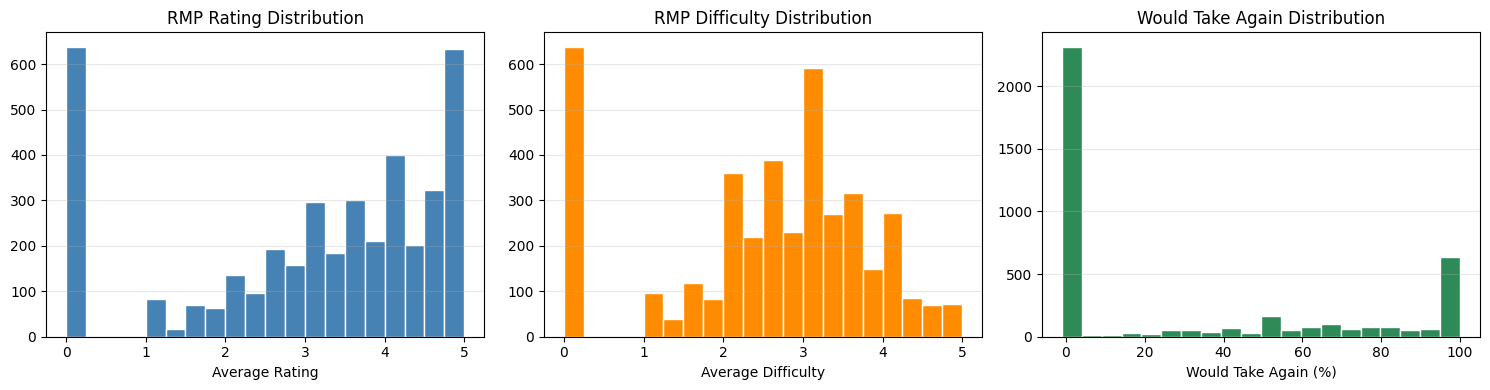

,avgRating,avgDifficulty,wouldTakeAgainPercent,numRatings
count,4003.000,4003.000,4003.000,4003.000
mean,3.078,2.494,30.415,16.570
std,1.647,1.341,40.598,30.361
min,0.000,0.000,-1.000,0.000
25%,2.200,2.000,-1.000,1.000
50%,3.500,2.800,-1.000,6.000
75%,4.400,3.400,66.667,19.000
max,5.000,5.000,100.000,446.000


In [7]:
rmp = ph.clean_rmp_frame(rmp_profs)
ph.plot_rmp_distributions(rmp, 'figures/rmp_distributions.png')
rmp[['avgRating', 'avgDifficulty', 'wouldTakeAgainPercent', 'numRatings']].describe().round(3)


### 4.3 Avg Rating by Department (Top 15 by count)

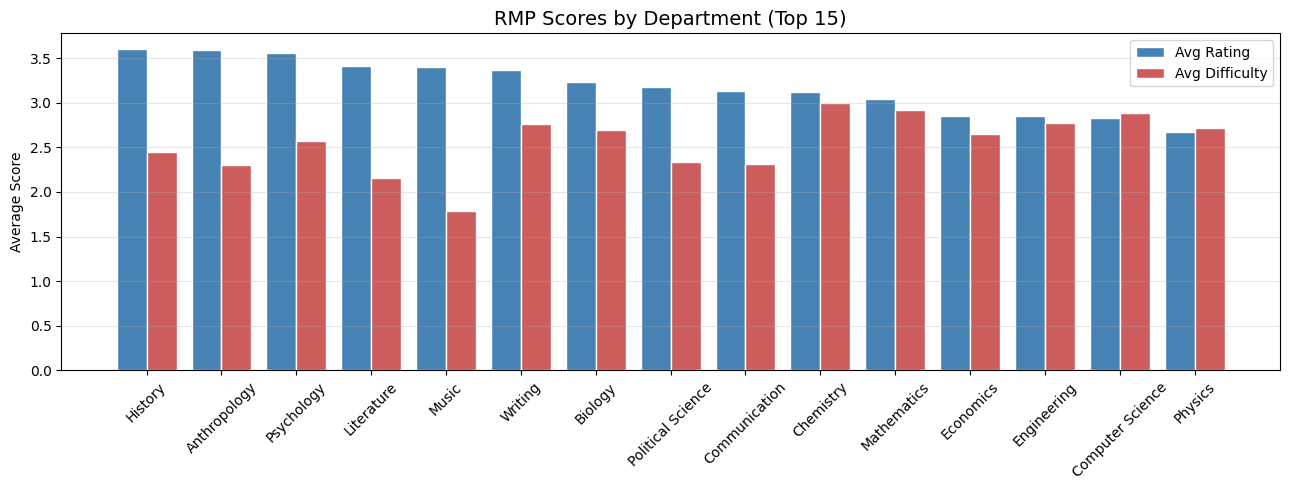

,avgRating,avgDifficulty
department,,
History,3.597,2.444
Anthropology,3.590,2.301
Psychology,3.559,2.574
Literature,3.412,2.162
Music,3.401,1.792
Writing,3.371,2.757
Biology,3.229,2.698
Political Science,3.175,2.335
Communication,3.136,2.319


In [8]:
dept_rating, top_depts_rmp = ph.summarize_rmp_departments(rmp)
ph.plot_rmp_department_summary(dept_rating, 'figures/rmp_dept_rating.png')
dept_rating.round(3)


### 4.4 Rating vs Difficulty — Scatter

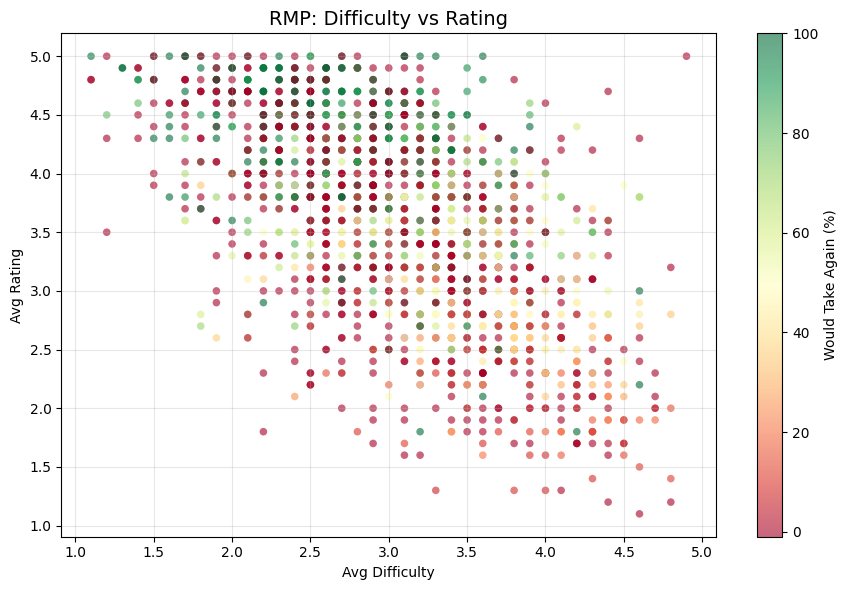

In [9]:
rmp_filtered = ph.filter_rmp_for_scatter(rmp)
ph.plot_rmp_difficulty_vs_rating(rmp_filtered, 'figures/rmp_difficulty_vs_rating.png')


## 5. Cross-Reference: RMP Rating vs CAPES GPA

In [10]:
capes_prof, rmp_summary, merged = ph.build_capes_rmp_match(df_clean, rmp)
print(f'Matched professors: {len(merged):,}')
merged.head()


Matched professors: 7,557


,Instructor,capes_gpa,capes_rec,last_name,avgRating,avgDifficulty,wouldTakeAgainPercent,numRatings
0,Aamari Eddie,3.007500,70.275000,Aamari,4.2,3.3,83.3333,6
1,Aarons Sarah Miranda,3.440000,94.300000,Aarons,2.7,3.7,0.0000,3
2,Abarbanel Henry Don Isaac,2.836667,65.533333,Abarbanel,2.4,3.3,0.0000,6
3,Abrajano Marisa,3.246667,82.650000,Abrajano,3.0,2.8,25.0000,42
4,Abramson Ian S,3.070000,82.300000,Abramson,3.6,3.1,-1.0000,18


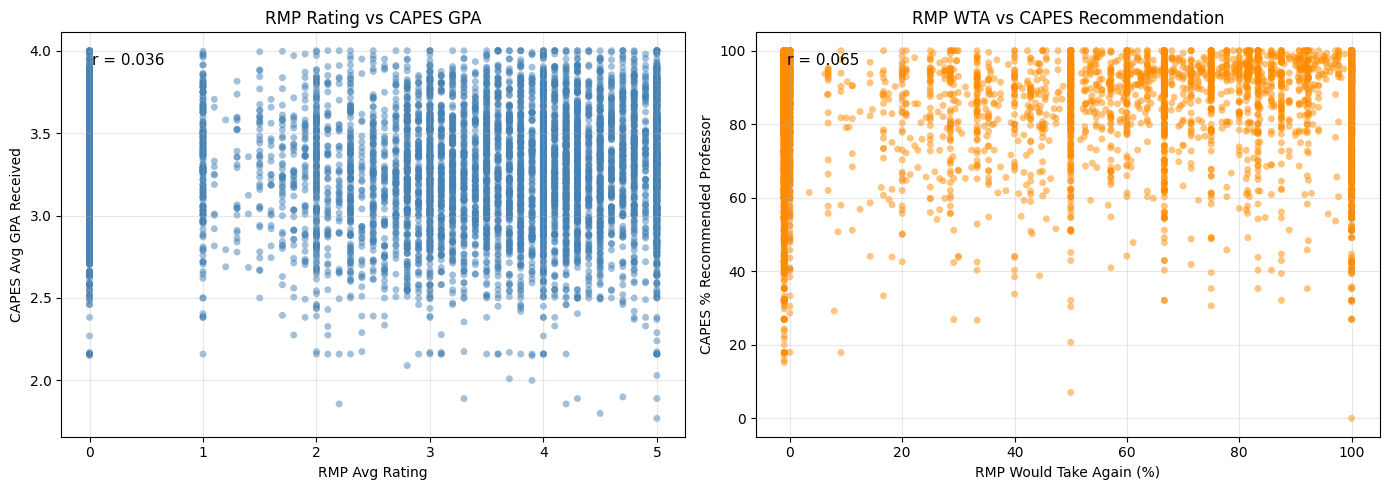

Correlation (RMP rating vs CAPES GPA): 0.036
Correlation (RMP WTA vs CAPES rec): 0.065


In [11]:
corr0, corr1 = ph.plot_capes_rmp_comparison(merged, 'figures/rmp_vs_capes_gpa.png')
print(f'Correlation (RMP rating vs CAPES GPA): {corr0:.3f}')
print(f'Correlation (RMP WTA vs CAPES rec): {corr1:.3f}')
